https://ivantsovy.com/research/paper2.pdf  
# 1st

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [86]:
def get_prewarped_omega(fc, fs, sigma):
    if fc > fs / 2:
        return fs / fc
    omega_raw = fs / fc
    ctg_val = 1.0 / np.tan(np.pi / omega_raw)
    denom = np.sqrt(sigma**2 + (np.pi * ctg_val)**2)
    return denom

def phi(x, sigma):
    if np.isinf(x):
        return -1.0
    val = np.sqrt(x**2 + sigma**2)
    return (np.pi - val) / (np.pi + val)

def get_first_order_coefficients(filter_type, fc, fs, sigma=2.0, gain_db=10.0):
    omega = get_prewarped_omega(fc, fs, sigma)
    g = 10 ** (gain_db / 20.0)
    alpha = 0.0; beta = 0.0; G = 0.0
    if filter_type.lower() in ["high pass", "hp"]:
        alpha = phi(np.inf, sigma); beta = phi(omega, sigma); G = omega / (2 * np.pi)
    elif filter_type.lower() in ["low pass", "lp"]:
        alpha = phi(0.0, sigma); beta = phi(omega, sigma); G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["all pass", "ap"]:
        beta = phi(omega, sigma); alpha = 1.0 / beta if beta != 0 else 0.0; G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["high shelf", "hs"]:
        alpha = phi(omega * np.sqrt(g), sigma); beta = phi(omega * np.sqrt(1.0 / g), sigma); G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["low shelf", "ls"]:
        alpha = phi(omega * np.sqrt(1.0 / g), sigma); beta = phi(omega * np.sqrt(g), sigma); G = g / (1.0 + alpha)
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")
    b0 = G * (1.0 + beta); b1 = G * (1.0 + beta) * alpha; a0 = 1.0; a1 = beta
    return [b0, b1], [a0, a1]

def get_first_order_coefficients2(filter_type, fc, fs, sigma=2.0, gain_db=10.0):
    omega = get_prewarped_omega(fc, fs, sigma)
    g = 10 ** (gain_db / 20.0)
    alpha = 0.0; beta = 0.0; G = 0.0
    s_g = 1
    if filter_type.lower() in ["high pass", "hp"]:
        alpha = phi(np.inf, sigma); beta = phi(omega, sigma); G = omega / (2 * np.pi)
        s_g = 0
    elif filter_type.lower() in ["low pass", "lp"]:
        alpha = phi(0.0, sigma); beta = phi(omega, sigma); G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["all pass", "ap"]:
        beta = phi(omega, sigma); alpha = 1.0 / beta if beta != 0 else 0.0; G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["high shelf", "hs"]:
        alpha = phi(omega * np.sqrt(g), sigma); beta = phi(omega * np.sqrt(1.0 / g), sigma); G = 1.0 / (1.0 + alpha)
    elif filter_type.lower() in ["low shelf", "ls"]:
        alpha = phi(omega * np.sqrt(1.0 / g), sigma); beta = phi(omega * np.sqrt(g), sigma); G = g / (1.0 + alpha)
        # TODO: 为什么这里是ge而不是1
        s_g = g
    else:
        raise ValueError(f"Unknown filter type: {filter_type}")
    return 1+beta, G, s_g

In [80]:
class Ivantsovy:
    def __init__(self):
        self.s = 0
        self.one_plus_beta = 0
        self.G = 0
        self.s_mix = 0
    
    def tick(self, x):
        t = self.one_plus_beta * (x - self.s)
        y = self.G * t + self.s * self.s_mix
        self.s = self.s + t
        return y
        
    def set(self, one_plus_beta, G, s_mix):
        self.one_plus_beta = one_plus_beta
        self.G = G
        self.s_mix = s_mix

class TDF2:
    """一阶 TDF2 (Transposed Direct Form 2)

           b0 + b1*z^-1
    H(z) = -------------
            1 + a1*z^-1
    """
    def __init__(self):
        self.s1 = 0.0
        self.b0 = 0.0
        self.b1 = 0.0
        self.a1 = 0.0

    def tick(self, x: float) -> float:
        y = self.b0 * x + self.s1
        self.s1 = self.b1 * x - self.a1 * y
        return y

    def set(self, b_v, a_v):
        self.b0 = b_v[0]
        self.b1 = b_v[1]
        self.a1 = a_v[1]

class SVF:
    """一阶 TPT-SVF (Trapezoidal State Variable Filter)

           b0 + b1*z^-1
    H(z) = -------------
            1 + a1*z^-1

    推导见 ivantsovy_1st_svf.ipynb

    TPT 隐式方程求解:
        hp = (x - s1) / (1+g)
        lp = g * hp + s1
        s1 = lp + g * hp

    BA → SVF 转换:
        g = (1 + a1) / (1 - a1)
        hp_gain = (b0 - b1) * (1+g) / 2
        lp_gain = (b0 + b1) * (1+g) / (2*g)
    """
    def __init__(self):
        self.s1 = 0.0
        self.g = 0.0
        self.hp_gain = 0.0
        self.lp_gain = 0.0

    def tick(self, x: float) -> float:
        hp = (x - self.s1) / (1.0 + self.g)
        lp = self.g * hp + self.s1
        self.s1 = lp + self.g * hp
        return self.hp_gain * hp + self.lp_gain * lp

    def set(self, b_v, a_v):
        b0, b1 = b_v
        a1 = a_v[1]
        self.g = (1.0 + a1) / (1.0 - a1)
        self.hp_gain = (b0 - b1) * (1.0 + self.g) / 2.0
        self.lp_gain = (b0 + b1) * (1.0 + self.g) / (2.0 * self.g)

class Lattice:
    """一阶 Lattice-Ladder (格型滤波器)

           b0 + b1*z^-1
    H(z) = -------------
            1 + a1*z^-1

    由二阶 LatticeBiquad (qwqdsp/filter/lattice_biquad.hpp)
    简化得到 (b2=0, a2=0):

    k1 = a1
    v0 = b0
    v1 = b1 - a1 * b0
    """
    def __init__(self):
        self.s1 = 0.0
        self.k1 = 0.0
        self.v0 = 0.0
        self.v1 = 0.0

    def tick(self, x: float) -> float:
        y = self.v0 * x + self.v1 * self.s1
        self.s1 = x - self.k1 * self.s1
        return y

    def set(self, b_v, a_v):
        b0, b1 = b_v
        a1 = a_v[1]
        self.k1 = a1
        self.v0 = b0
        self.v1 = b1 - a1 * b0


===== LPF fc=1000Hz =====
  b = [0.1087989756, 0.0241567389]
  a = [1.0000000000, -0.8670442854]
  one_plus_beta=0.1329557146, G=0.8183098862, s_mix=1


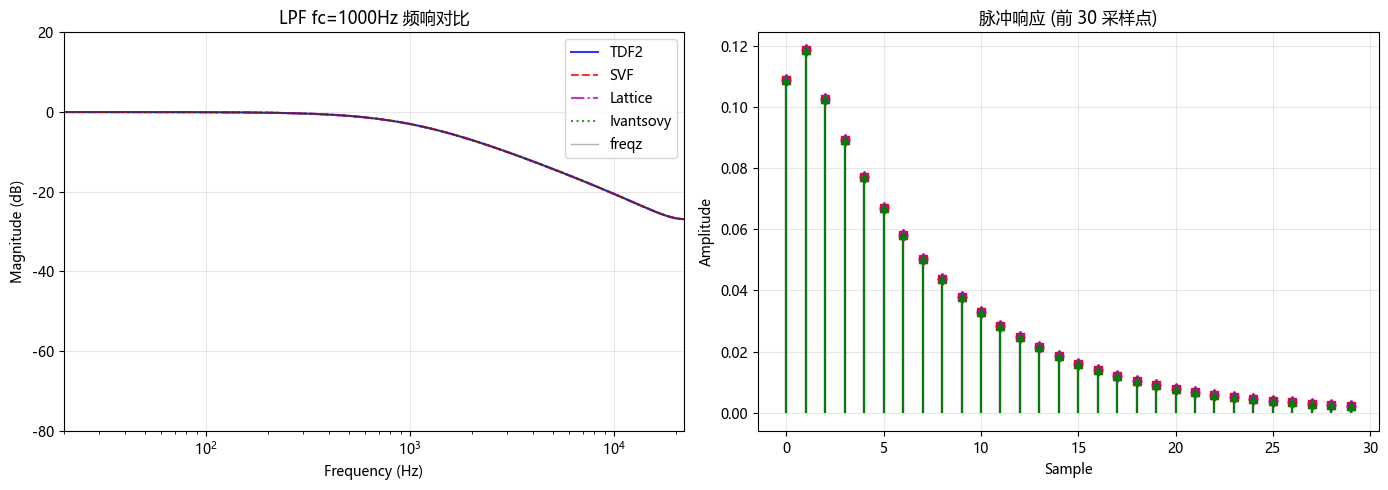


--- LPF 脉冲响应差异 (RMS) ---
TDF2       vs SVF         RMS: 5.36e-19
TDF2       vs Lattice     RMS: 1.45e-19
TDF2       vs Ivantsovy   RMS: 2.81e-19
SVF        vs Lattice     RMS: 5.87e-19
SVF        vs Ivantsovy   RMS: 4.99e-19
Lattice    vs Ivantsovy   RMS: 2.87e-19

===== HPF fc=1000Hz =====
  b = [0.9325623378, -0.9325623378]
  a = [1.0000000000, -0.8670442854]
  one_plus_beta=0.1329557146, G=7.0140824030, s_mix=0


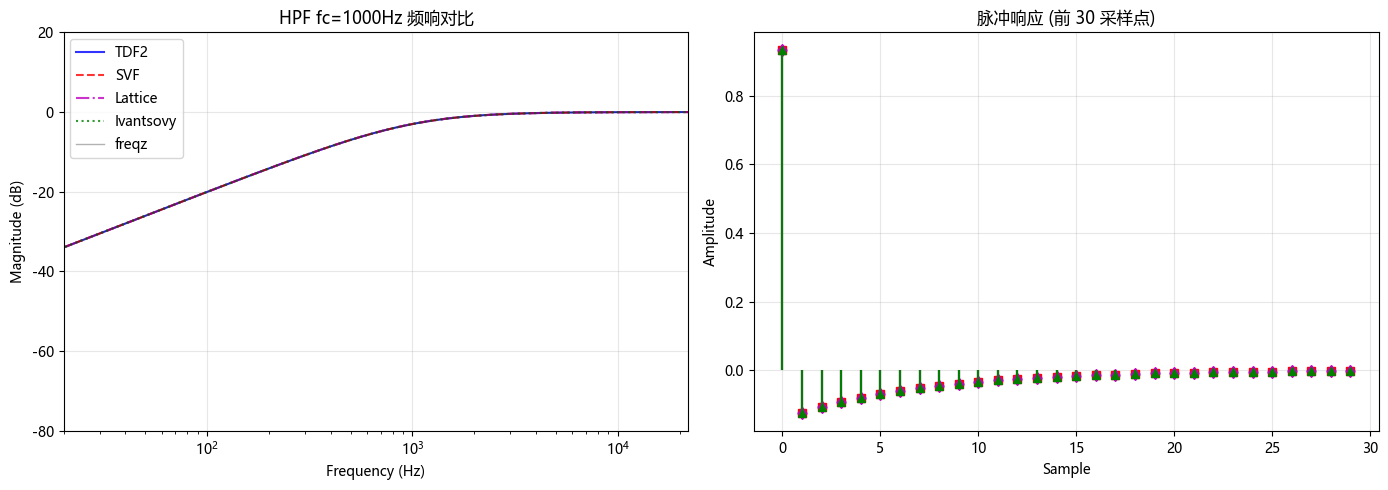


--- HPF 脉冲响应差异 (RMS) ---
TDF2       vs SVF         RMS: 7.63e-19
TDF2       vs Lattice     RMS: 2.45e-19
TDF2       vs Ivantsovy   RMS: 5.16e-19
SVF        vs Lattice     RMS: 8.69e-19
SVF        vs Ivantsovy   RMS: 5.07e-19
Lattice    vs Ivantsovy   RMS: 5.84e-19

===== APF fc=1000Hz =====
  b = [-0.8670442854, 1.0000000000]
  a = [1.0000000000, -0.8670442854]
  one_plus_beta=0.1329557146, G=-6.5213013850, s_mix=1


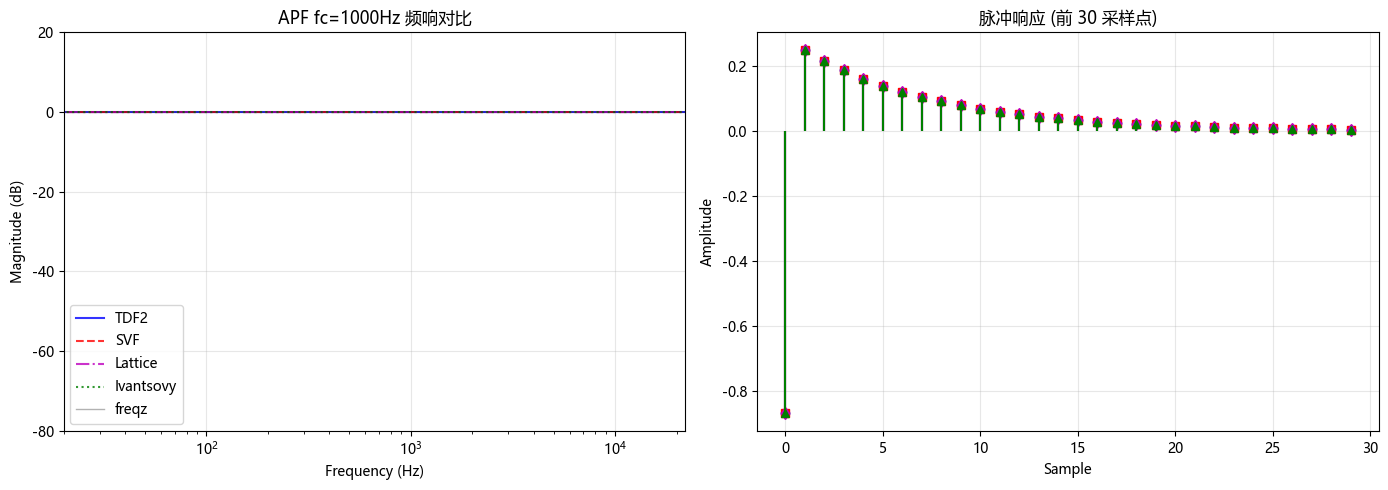


--- APF 脉冲响应差异 (RMS) ---
TDF2       vs SVF         RMS: 6.97e-19
TDF2       vs Lattice     RMS: 7.99e-19
TDF2       vs Ivantsovy   RMS: 9.96e-19
SVF        vs Lattice     RMS: 1.29e-18
SVF        vs Ivantsovy   RMS: 1.34e-18
Lattice    vs Ivantsovy   RMS: 6.80e-19

===== LSF fc=1000Hz =====
  b = [1.0861233767, -0.8424412302]
  a = [1.0000000000, -0.9229409392]
  one_plus_beta=0.0770590608, G=14.0946874421, s_mix=3.1622776601683795


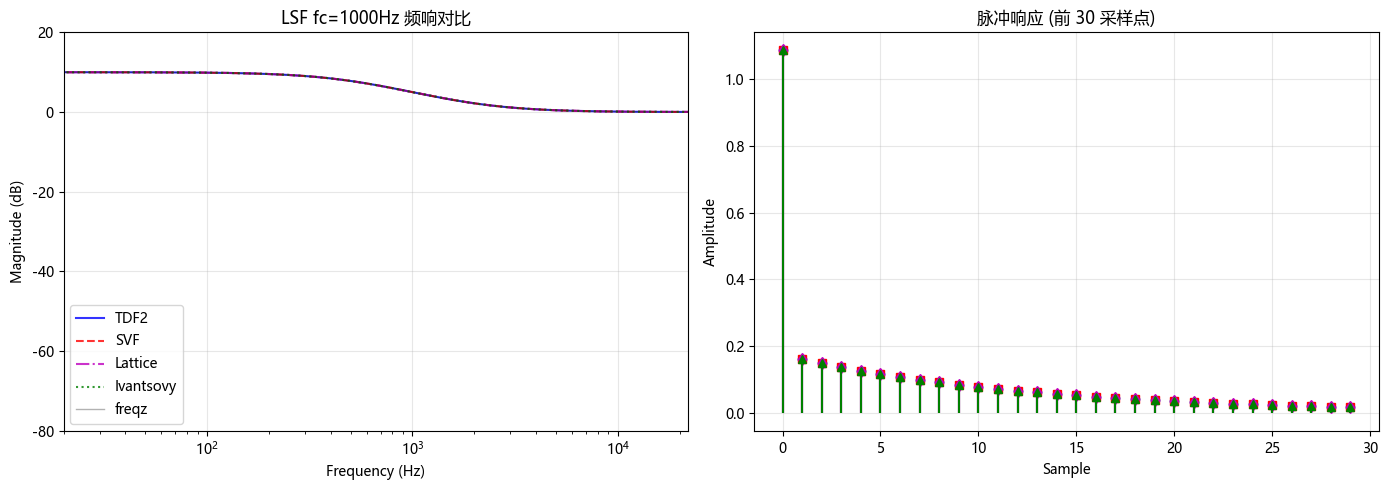


--- LSF 脉冲响应差异 (RMS) ---
TDF2       vs SVF         RMS: 1.06e-18
TDF2       vs Lattice     RMS: 5.72e-19
TDF2       vs Ivantsovy   RMS: 2.61e-18
SVF        vs Lattice     RMS: 1.29e-18
SVF        vs Ivantsovy   RMS: 3.47e-18
Lattice    vs Ivantsovy   RMS: 2.57e-18

===== HSF fc=1000Hz =====
  b = [2.9115271138, -2.6871675689]
  a = [1.0000000000, -0.7756404551]
  one_plus_beta=0.2243595449, G=12.9770592774, s_mix=1


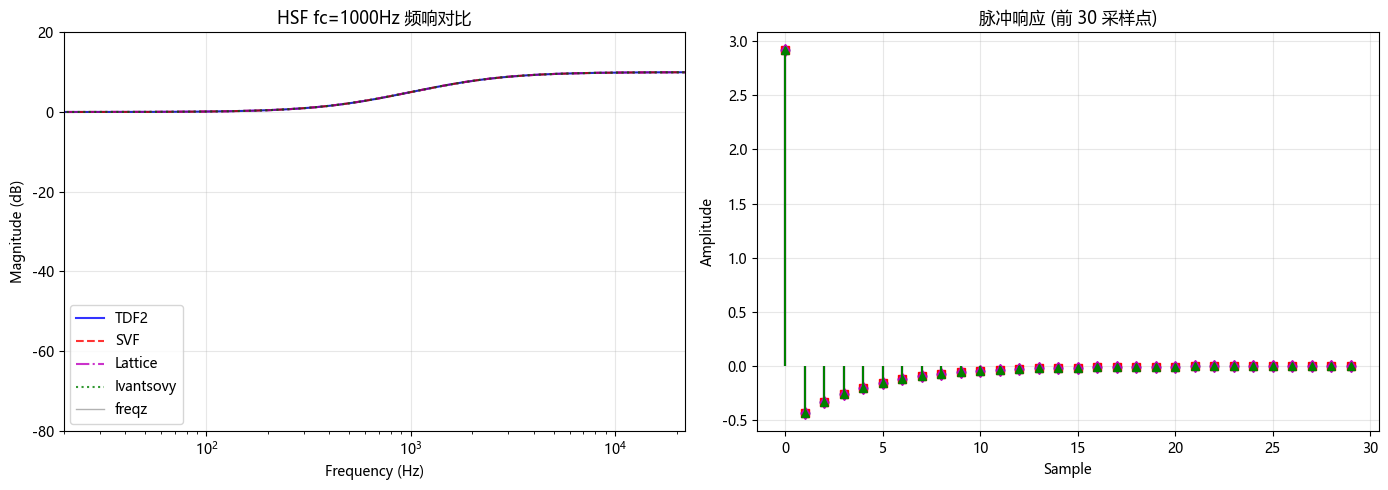


--- HSF 脉冲响应差异 (RMS) ---
TDF2       vs SVF         RMS: 1.60e-18
TDF2       vs Lattice     RMS: 5.12e-19
TDF2       vs Ivantsovy   RMS: 1.76e-18
SVF        vs Lattice     RMS: 1.86e-18
SVF        vs Ivantsovy   RMS: 2.81e-18
Lattice    vs Ivantsovy   RMS: 1.67e-18


In [87]:
# ==========================================
# 一阶滤波器对比测试函数
# ==========================================

def test_first_order(filter_type, fc=1000.0, fs=44100.0, sigma=2.0):
    """测试四种一阶滤波器结构的脉冲响应一致性"""
    b, a = get_first_order_coefficients(filter_type, fc, fs, sigma=sigma)
    one_plus_beta, G, s_mix = get_first_order_coefficients2(filter_type, fc, fs, sigma=sigma)
    name_map = {"lp": "LPF", "hp": "HPF", "ap": "APF", "ls": "LSF", "hs": "HSF"}
    name = name_map.get(filter_type, filter_type.upper())
    print(f"\n===== {name} fc={fc}Hz =====")
    print(f"  b = [{b[0]:.10f}, {b[1]:.10f}]")
    print(f"  a = [{a[0]:.10f}, {a[1]:.10f}]")
    print(f"  one_plus_beta={one_plus_beta:.10f}, G={G:.10f}, s_mix={s_mix}")

    tdf2 = TDF2(); svf = SVF(); iv = Ivantsovy(); lat = Lattice()
    tdf2.set(b, a); svf.set(b, a); lat.set(b, a); iv.set(one_plus_beta, G, s_mix)

    N = 8192
    impulse = np.zeros(N); impulse[0] = 1.0

    out_tdf2 = np.array([tdf2.tick(x) for x in impulse])
    out_svf  = np.array([svf.tick(x)  for x in impulse])
    out_lat  = np.array([lat.tick(x)  for x in impulse])
    iv = Ivantsovy(); iv.set(one_plus_beta, G, s_mix)
    out_iv   = np.array([iv.tick(x) for x in impulse])

    freq = np.fft.rfftfreq(N, 1/fs)
    w, h_ref = signal.freqz(b, a, worN=N, fs=fs)
    H_ref = 20 * np.log10(np.abs(h_ref) + 1e-15)
    name_map = {"lp": "LPF", "hp": "HPF", "ap": "APF", "ls": "LSF", "hs": "HSF"}

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    for data, c, ls in [(out_tdf2, 'b', '-'), (out_svf, 'r', '--'), (out_lat, 'm', '-.'), (out_iv, 'g', ':')]:
        H = 20 * np.log10(np.abs(np.fft.rfft(data)) + 1e-15)
        plt.plot(freq, H, c+ls, lw=1.5, alpha=0.8)
    plt.plot(w, H_ref, 'k-', label='freqz ref', lw=1, alpha=0.3)
    plt.xscale('log'); plt.xlim(20, fs/2); plt.ylim(-80, 20)
    plt.xlabel('Frequency (Hz)'); plt.ylabel('Magnitude (dB)')
    plt.title(f'{name_map.get(filter_type, filter_type.upper())} fc={fc}Hz 频响对比')
    plt.grid(True, alpha=0.3); plt.legend(['TDF2','SVF','Lattice','Ivantsovy','freqz'])

    plt.subplot(1, 2, 2)
    n_show = 30
    for data, c, m in [(out_tdf2, 'b', 'o'), (out_svf, 'r', 's'), (out_lat, 'm', 'd'), (out_iv, 'g', '^')]:
        plt.stem(range(n_show), data[:n_show], linefmt=c+'-', markerfmt=c+m, basefmt=' ')
    plt.xlabel('Sample'); plt.ylabel('Amplitude')
    plt.title('脉冲响应 (前 30 采样点)'); plt.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    pairs = [("TDF2", out_tdf2), ("SVF", out_svf), ("Lattice", out_lat), ("Ivantsovy", out_iv)]
    print(f"\n--- {name_map.get(filter_type, filter_type.upper())} 脉冲响应差异 (RMS) ---")
    for i, (n1, o1) in enumerate(pairs):
        for n2, o2 in pairs[i+1:]:
            print(f"{n1:10s} vs {n2:10s}  RMS: {np.sqrt(np.mean((o1-o2)**2)):.2e}")

# === 运行测试 ===
test_first_order("lp", 1000)
test_first_order("hp", 1000)
test_first_order("ap", 1000)
test_first_order("ls", 1000)
test_first_order("hs", 1000)

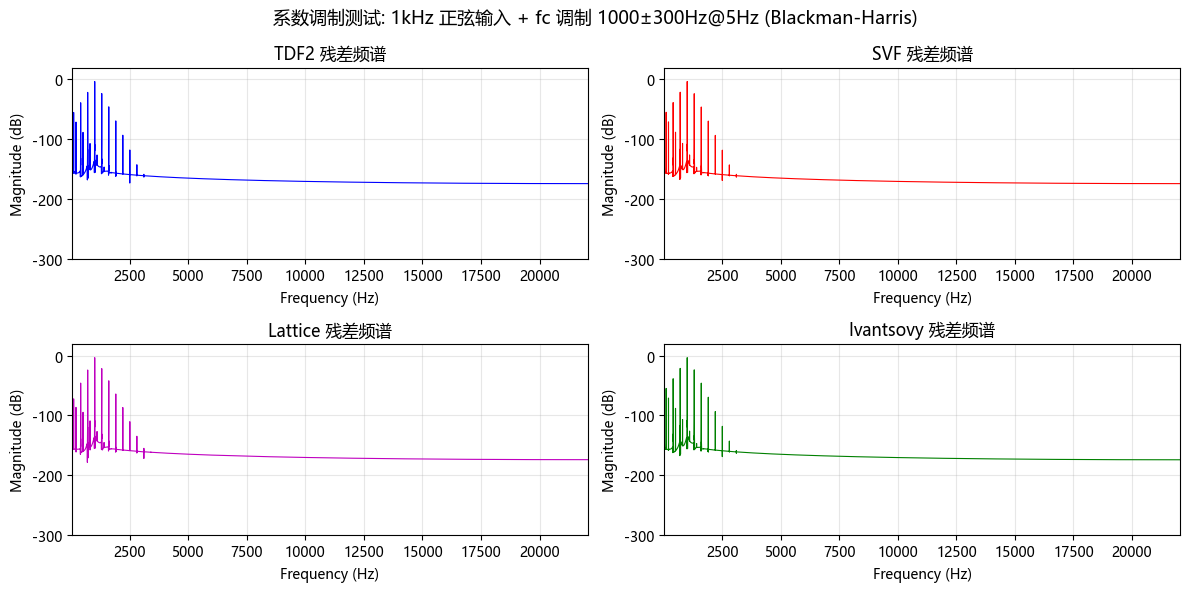


--- 残差统计 ---
TDF2        Peak: 8.031876e-01  RMS: 4.845752e-01
SVF         Peak: 8.045657e-01  RMS: 4.847971e-01
Lattice     Peak: 7.953104e-01  RMS: 4.840920e-01
Ivantsovy   Peak: 8.045657e-01  RMS: 4.847971e-01


In [35]:
# ==========================================
# 系数调制测试: 1kHz 正弦波 + fc 调制
# ==========================================

N_mod = 2**16
fs = 44100.0
sigma = 2.0

t_axis = np.arange(N_mod) / fs

# 输入: 1kHz 正弦波
x_in = np.sin(2 * np.pi * 1000 * t_axis)

# fc 调制: 1000 + 300*sin(2π*5*t)
fc_mod = 1000.0 + 300.0 * np.sin(2 * np.pi * 300 * t_axis)

# 四个滤波器实例
tdf2_m = TDF2()
svf_m  = SVF()
lat_m  = Lattice()
iv_m   = Ivantsovy()

out_tdf2_m = np.zeros(N_mod)
out_svf_m  = np.zeros(N_mod)
out_lat_m  = np.zeros(N_mod)
out_iv_m   = np.zeros(N_mod)

for n in range(N_mod):
    fc = fc_mod[n]
    b, a = get_first_order_coefficients("lp", fc, fs, sigma=sigma)
    one_plus_beta, G, s_mix = get_first_order_coefficients2("lp", fc, fs, sigma=sigma)

    tdf2_m.set(b, a)
    svf_m.set(b, a)
    lat_m.set(b, a)
    iv_m.set(one_plus_beta, G, s_mix)

    out_tdf2_m[n] = tdf2_m.tick(x_in[n])
    out_svf_m[n]  = svf_m.tick(x_in[n])
    out_lat_m[n]  = lat_m.tick(x_in[n])
    out_iv_m[n]   = iv_m.tick(x_in[n])

# 取输入减去输出作为残差
err_tdf2 = x_in - out_tdf2_m
err_svf  = x_in - out_svf_m
err_lat  = x_in - out_lat_m
err_iv   = x_in - out_iv_m

# Blackman-Harris 窗
win = np.blackman(N_mod)  # 标准 Blackman, scipy 没有 blackman_harris 内置
# 手动实现 4-term Blackman-Harris
a0, a1, a2, a3 = 0.35875, 0.48829, 0.14128, 0.01168
win = a0 - a1 * np.cos(2*np.pi*np.arange(N_mod)/N_mod) \
         + a2 * np.cos(4*np.pi*np.arange(N_mod)/N_mod) \
         - a3 * np.cos(6*np.pi*np.arange(N_mod)/N_mod)

win_norm = 2.0 / np.sum(win)

# 加窗频谱
freq = np.fft.rfftfreq(N_mod, 1/fs)
E_tdf2 = 20 * np.log10(np.abs(np.fft.rfft(err_tdf2 * win)) * win_norm + 1e-15)
E_svf  = 20 * np.log10(np.abs(np.fft.rfft(err_svf  * win)) * win_norm + 1e-15)
E_lat  = 20 * np.log10(np.abs(np.fft.rfft(err_lat  * win)) * win_norm + 1e-15)
E_iv   = 20 * np.log10(np.abs(np.fft.rfft(err_iv   * win)) * win_norm + 1e-15)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(freq, E_tdf2, 'b-', lw=0.8)
plt.title('TDF2 残差频谱')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-300, 20)

plt.subplot(2, 2, 2)
plt.plot(freq, E_svf, 'r-', lw=0.8)
plt.title('SVF 残差频谱')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-300, 20)

plt.subplot(2, 2, 3)
plt.plot(freq, E_lat, 'm-', lw=0.8)
plt.title('Lattice 残差频谱')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-300, 20)

plt.subplot(2, 2, 4)
plt.plot(freq, E_iv, 'g-', lw=0.8)
plt.title('Ivantsovy 残差频谱')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-300, 20)

plt.suptitle('系数调制测试: 1kHz 正弦输入 + fc 调制 1000±300Hz@5Hz (Blackman-Harris)', fontsize=13)
plt.tight_layout()
plt.show()

# === Peak / RMS ===
print(f"\n--- 残差统计 ---")
for name, err in [("TDF2", err_tdf2), ("SVF", err_svf),
                   ("Lattice", err_lat), ("Ivantsovy", err_iv)]:
    peak = np.max(np.abs(err))
    rms  = np.sqrt(np.mean(err**2))
    print(f"{name:10s}  Peak: {peak:.6e}  RMS: {rms:.6e}")

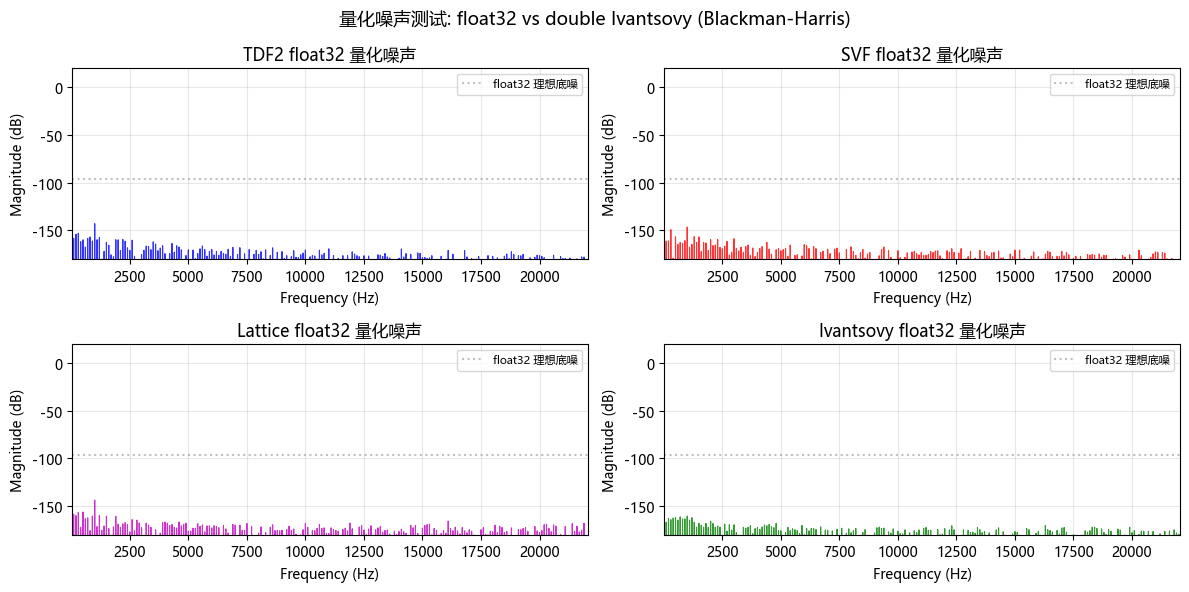


--- float32 量化噪声 (vs double Ivantsovy) ---
TDF2        Noise RMS: 6.801482e-08  Peak: 2.167253e-07  SNR: 137.3 dB
SVF         Noise RMS: 5.766489e-08  Peak: 1.713627e-07  SNR: 138.8 dB
Lattice     Noise RMS: 5.894712e-08  Peak: 1.728381e-07  SNR: 138.6 dB
Ivantsovy   Noise RMS: 2.618478e-08  Peak: 9.072745e-08  SNR: 145.6 dB


In [36]:
# ==========================================
# 量化噪声测试: float32 vs double Ivantsovy
# ==========================================

N_q = 2**16
fs = 44100.0
sigma = 2.0
fc = 1000.0

t_axis = np.arange(N_q) / fs
x_in = np.sin(2 * np.pi * 1000 * t_axis)

# 双精度 Ivantsovy 参考
b, a = get_first_order_coefficients("lp", fc, fs, sigma=sigma)
one_plus_beta, G, s_mix = get_first_order_coefficients2("lp", fc, fs, sigma=sigma)

iv_ref = Ivantsovy()
iv_ref.set(one_plus_beta, G, s_mix)
ref = np.array([iv_ref.tick(x) for x in x_in])

# float32 模拟: 将系数和状态截断为 float32
def run_float32(filter_obj, set_fn, x_in, b, a):
    """用 float32 模拟运行滤波器"""
    out = np.zeros(len(x_in))
    for n, x in enumerate(x_in):
        x32 = np.float32(x)
        set_fn(filter_obj, [np.float32(b[0]), np.float32(b[1])],
                          [np.float32(1.0), np.float32(a[1])])
        # 强制 state 为 float32
        if hasattr(filter_obj, 's1'):
            filter_obj.s1 = np.float32(filter_obj.s1)
        y = filter_obj.tick(x32)
        out[n] = float(y)
    return out

def run_float32_iv(filter_obj, x_in, one_plus_beta, G, s_mix):
    out = np.zeros(len(x_in))
    for n, x in enumerate(x_in):
        x32 = np.float32(x)
        filter_obj.set(np.float32(one_plus_beta), np.float32(G), s_mix)
        filter_obj.s = np.float32(filter_obj.s)
        y = filter_obj.tick(x32)
        out[n] = float(y)
    return out

def set_b_a(f, b_v, a_v):
    f.set(b_v, a_v)

tdf2_f32 = run_float32(TDF2(), set_b_a, x_in, b, a)
svf_f32  = run_float32(SVF(),  set_b_a, x_in, b, a)
lat_f32  = run_float32(Lattice(), set_b_a, x_in, b, a)
iv_f32   = run_float32_iv(Ivantsovy(), x_in, one_plus_beta, G, s_mix)

# 量化误差
err_tdf2 = ref - tdf2_f32
err_svf  = ref - svf_f32
err_lat  = ref - lat_f32
err_iv   = ref - iv_f32

# Blackman-Harris
a0, a1, a2, a3 = 0.35875, 0.48829, 0.14128, 0.01168
win = a0 - a1 * np.cos(2*np.pi*np.arange(N_q)/N_q) \
         + a2 * np.cos(4*np.pi*np.arange(N_q)/N_q) \
         - a3 * np.cos(6*np.pi*np.arange(N_q)/N_q)
win_norm = 2.0 / np.sum(win)

freq = np.fft.rfftfreq(N_q, 1/fs)
E_tdf2 = 20 * np.log10(np.abs(np.fft.rfft(err_tdf2 * win)) * win_norm + 1e-15)
E_svf  = 20 * np.log10(np.abs(np.fft.rfft(err_svf  * win)) * win_norm + 1e-15)
E_lat  = 20 * np.log10(np.abs(np.fft.rfft(err_lat  * win)) * win_norm + 1e-15)
E_iv   = 20 * np.log10(np.abs(np.fft.rfft(err_iv   * win)) * win_norm + 1e-15)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(freq, E_tdf2, 'b-', lw=0.8, alpha=0.8)
plt.title('TDF2 float32 量化噪声')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-180, 20)
plt.axhline(-96, color='gray', ls=':', alpha=0.5, label='float32 理想底噪')
plt.legend(fontsize=8)

plt.subplot(2, 2, 2)
plt.plot(freq, E_svf, 'r-', lw=0.8, alpha=0.8)
plt.title('SVF float32 量化噪声')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-180, 20)
plt.axhline(-96, color='gray', ls=':', alpha=0.5, label='float32 理想底噪')
plt.legend(fontsize=8)

plt.subplot(2, 2, 3)
plt.plot(freq, E_lat, 'm-', lw=0.8, alpha=0.8)
plt.title('Lattice float32 量化噪声')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-180, 20)
plt.axhline(-96, color='gray', ls=':', alpha=0.5, label='float32 理想底噪')
plt.legend(fontsize=8)

plt.subplot(2, 2, 4)
plt.plot(freq, E_iv, 'g-', lw=0.8, alpha=0.8)
plt.title('Ivantsovy float32 量化噪声')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.xlim(20, fs/2)
plt.ylim(-180, 20)
plt.axhline(-96, color='gray', ls=':', alpha=0.5, label='float32 理想底噪')
plt.legend(fontsize=8)

plt.suptitle('量化噪声测试: float32 vs double Ivantsovy (Blackman-Harris)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n--- float32 量化噪声 (vs double Ivantsovy) ---")
for name, err in [("TDF2", err_tdf2), ("SVF", err_svf),
                   ("Lattice", err_lat), ("Ivantsovy", err_iv)]:
    n_rms = np.sqrt(np.mean(err**2))
    n_peak = np.max(np.abs(err))
    snr = 20 * np.log10(np.sqrt(np.mean(ref**2)) / n_rms)
    print(f"{name:10s}  Noise RMS: {n_rms:.6e}  Peak: {n_peak:.6e}  SNR: {snr:.1f} dB")

# 2nd

In [ ]:
def phi_1st(x, sigma):
    if np.isinf(x): return -1.0
    val = np.sqrt(x**2 + sigma**2)
    return (np.pi - val) / (np.pi + val)

def nu(x, y, sigma):
    return np.sqrt(x**4 + 2 * (x**2) * (sigma**2) * (2 * y**2 - 1) + sigma**4)

def kappa(x, y, sigma):
    return x**2 * (2 * y**2 - 1) + sigma**2

def phi1_2nd(x, y, sigma):
    v_val = nu(x, y, sigma)
    k_val = kappa(x, y, sigma)
    denom = np.pi**2 + np.pi * np.sqrt(2) * np.sqrt(v_val + k_val) + v_val
    return (2 * np.pi**2 - 2 * v_val) / denom

def phi2_2nd(x, y, sigma):
    v_val = nu(x, y, sigma)
    k_val = kappa(x, y, sigma)
    denom = np.pi**2 + np.pi * np.sqrt(2) * np.sqrt(v_val + k_val) + v_val
    return (np.pi**2 - np.pi * np.sqrt(2) * np.sqrt(v_val + k_val) + v_val) / denom

def get_second_order_coefficients_v2(filter_type, fc, fs, zeta=1.0/np.sqrt(2), sigma=2.0, gain_db=10.0, use_simplified_notch=True):
    omega = get_prewarped_omega(fc, fs, sigma)
    g = 10 ** (gain_db / 20.0)
    
    alpha1, alpha2 = 0.0, 0.0
    beta1, beta2 = 0.0, 0.0
    G = 0.0
    
    # 统一计算分母反馈系数 (所有二阶类型分母相同)
    beta1 = phi1_2nd(omega, zeta, sigma)
    beta2 = phi2_2nd(omega, zeta, sigma)
    
    if filter_type.lower() in ["band stop", "notch"]:
        if use_simplified_notch:
            # 采用论文公式 (3.9) 的高效简化版
            num = omega**2 - np.pi**2 - sigma**2
            denom_alpha = omega**2 + np.pi**2 - sigma**2
            alpha1 = -2.0 * (num / denom_alpha)
            alpha2 = 1.0
        else:
            # 采用 Table 3.1 的标准版: phi_1(omega, 0), phi_2(omega, 0)
            alpha1 = phi1_2nd(omega, 0.0, sigma)
            alpha2 = phi2_2nd(omega, 0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["low pass", "lp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(0.0, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high pass", "hp"]:
        alpha1 = phi_1st(np.inf, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(np.inf, sigma) * phi_1st(np.inf, sigma)
        G = omega**2 / (4 * np.pi**2)
    elif filter_type.lower() in ["band pass", "bp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(np.inf, sigma)
        G = (omega / (2 * np.pi)) * (2 * zeta / (2 + alpha1))
    elif filter_type.lower() in ["band shelf", "bs"]:
        alpha1 = phi1_2nd(omega, zeta * g**0.5, sigma)
        alpha2 = phi2_2nd(omega, zeta * g**0.5, sigma)
        beta1 = phi1_2nd(omega, zeta * g**-0.5, sigma)
        beta2 = phi2_2nd(omega, zeta * g**-0.5, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high shelf", "hs"]:
        alpha1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
        beta1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
    elif filter_type.lower() in ["low shelf", "ls"]:
        alpha1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
        beta1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = g / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["all pass", "ap"]:
        alpha1 = beta1 / beta2
        alpha2 = 1.0 / beta2
        G = 1.0 / (1.0 + alpha1 + alpha2)
    else:
        raise ValueError(f"Unsupported filter type: {filter_type}")

    # 还原传输函数系数
    scale = G * (1.0 + beta1 + beta2)
    b = [scale, scale * alpha1, scale * alpha2]
    a = [1.0, beta1, beta2]
    
    return b, a

def get_second_order_coefficients_v3(filter_type, fc, fs, zeta=1.0/np.sqrt(2), sigma=2.0, gain_db=10.0, use_simplified_notch=True):
    omega = get_prewarped_omega(fc, fs, sigma)
    g = 10 ** (gain_db / 20.0)
    
    alpha1, alpha2 = 0.0, 0.0
    beta1, beta2 = 0.0, 0.0
    G = 0.0
    
    # 统一计算分母反馈系数 (所有二阶类型分母相同)
    beta1 = phi1_2nd(omega, zeta, sigma)
    beta2 = phi2_2nd(omega, zeta, sigma)
    
    if filter_type.lower() in ["band stop", "notch"]:
        if use_simplified_notch:
            # 采用论文公式 (3.9) 的高效简化版
            num = omega**2 - np.pi**2 - sigma**2
            denom_alpha = omega**2 + np.pi**2 - sigma**2
            alpha1 = -2.0 * (num / denom_alpha)
            alpha2 = 1.0
        else:
            # 采用 Table 3.1 的标准版: phi_1(omega, 0), phi_2(omega, 0)
            alpha1 = phi1_2nd(omega, 0.0, sigma)
            alpha2 = phi2_2nd(omega, 0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["low pass", "lp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(0.0, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high pass", "hp"]:
        alpha1 = phi_1st(np.inf, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(np.inf, sigma) * phi_1st(np.inf, sigma)
        G = omega**2 / (4 * np.pi**2)
    elif filter_type.lower() in ["band pass", "bp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(np.inf, sigma)
        G = (omega / (2 * np.pi)) * (2 * zeta / (2 + alpha1))
    elif filter_type.lower() in ["band shelf", "bs"]:
        alpha1 = phi1_2nd(omega, zeta * g**0.5, sigma)
        alpha2 = phi2_2nd(omega, zeta * g**0.5, sigma)
        beta1 = phi1_2nd(omega, zeta * g**-0.5, sigma)
        beta2 = phi2_2nd(omega, zeta * g**-0.5, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high shelf", "hs"]:
        alpha1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
        beta1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
    elif filter_type.lower() in ["low shelf", "ls"]:
        alpha1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
        beta1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = g / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["all pass", "ap"]:
        alpha1 = beta1 / beta2
        alpha2 = 1.0 / beta2
        G = 1.0 / (1.0 + alpha1 + alpha2)
    else:
        raise ValueError(f"Unsupported filter type: {filter_type}")

    s_down_mix = 1
    if filter_type.lower() in ["high pass", "hp"]:
        alpha2 = 1
        s_down_mix = 0
    
    return 1+beta1+beta2,beta2,alpha2,G,s_down_mix

def get_second_order_coefficients_v4(filter_type, fc, fs, zeta=1.0/np.sqrt(2), sigma=2.0, gain_db=10.0, use_simplified_notch=True):
    omega = get_prewarped_omega(fc, fs, sigma)
    g = 10 ** (gain_db / 20.0)
    
    alpha1, alpha2 = 0.0, 0.0
    beta1, beta2 = 0.0, 0.0
    G = 0.0
    y_s1_mix = 1
    
    # 统一计算分母反馈系数 (所有二阶类型分母相同)
    beta1 = phi1_2nd(omega, zeta, sigma)
    beta2 = phi2_2nd(omega, zeta, sigma)
    v = nu(omega, zeta, sigma)
    
    if filter_type.lower() in ["band stop", "notch"]:
        if use_simplified_notch:
            # 采用论文公式 (3.9) 的高效简化版
            num = omega**2 - np.pi**2 - sigma**2
            denom_alpha = omega**2 + np.pi**2 - sigma**2
            alpha1 = -2.0 * (num / denom_alpha)
            alpha2 = 1.0
        else:
            # 采用 Table 3.1 的标准版: phi_1(omega, 0), phi_2(omega, 0)
            alpha1 = phi1_2nd(omega, 0.0, sigma)
            alpha2 = phi2_2nd(omega, 0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["low pass", "lp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(0.0, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(0.0, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high pass", "hp"]:
        alpha1 = phi_1st(np.inf, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(np.inf, sigma) * phi_1st(np.inf, sigma)
        G = omega**2 / (4 * np.pi**2)
        y_s1_mix = 0
    elif filter_type.lower() in ["band pass", "bp"]:
        alpha1 = phi_1st(0.0, sigma) + phi_1st(np.inf, sigma)
        alpha2 = phi_1st(0.0, sigma) * phi_1st(np.inf, sigma)
        G = (omega / (2 * np.pi)) * (2 * zeta / (2 + alpha1))
    elif filter_type.lower() in ["band shelf", "bs"]:
        alpha1 = phi1_2nd(omega, zeta * g**0.5, sigma)
        alpha2 = phi2_2nd(omega, zeta * g**0.5, sigma)
        beta1 = phi1_2nd(omega, zeta * g**-0.5, sigma)
        beta2 = phi2_2nd(omega, zeta * g**-0.5, sigma)
        v = nu(omega, zeta * g**-0.5, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
    elif filter_type.lower() in ["high shelf", "hs"]:
        alpha1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = 1.0 / (1.0 + alpha1 + alpha2)
        beta1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
        v = nu(omega * g**-0.25, zeta, sigma)
    elif filter_type.lower() in ["low shelf", "ls"]:
        alpha1 = phi1_2nd(omega * g**-0.25, zeta, sigma)
        alpha2 = phi2_2nd(omega * g**-0.25, zeta, sigma)
        beta1 = phi1_2nd(omega * g**0.25, zeta, sigma)
        beta2 = phi2_2nd(omega * g**0.25, zeta, sigma)
        G = g / (1.0 + alpha1 + alpha2)
        v = nu(omega * g**0.25, zeta, sigma)
    elif filter_type.lower() in ["all pass", "ap"]:
        alpha1 = beta1 / beta2
        alpha2 = 1.0 / beta2
        G = 1.0 / (1.0 + alpha1 + alpha2)
    else:
        raise ValueError(f"Unsupported filter type: {filter_type}")

    u = np.sqrt(v) / np.pi
    y_s2_mix = (1- alpha1 + alpha2) / u
    
    return u, 1+beta1+beta2, y_s1_mix, y_s2_mix, G

In [ ]:
class Ivantsovy2:
    """二阶 Ivantsovy 状态空间滤波器
    
           b0 + b1*z^-1 + b2*z^-2
    H(z) = ------------------------
            1 + a1*z^-1 + a2*z^-2
    """
    def __init__(self):
        self.s_up = 0
        self.s_down = 0
        self.one_plus_b1_b2 = 0
        self.G = 0
        self.beta2 = 0
        self.alpha2 = 0
        self.s_down_mix = 0
        
    def tick(self, x):
        t = (x - self.s_down) * self.one_plus_b1_b2 + self.s_up * self.beta2
        y = (t - self.s_up * self.alpha2) * self.G + self.s_down * self.s_down_mix
        self.s_down += t
        self.s_up = t
        return y
        
    # v3 returns: (1+beta1+beta2, beta2, alpha2, G, s_down_mix)
    def set(self, one_plus_beta1_beta2, beta2, alpha2, G, s_down_mix):
        self.one_plus_b1_b2 = one_plus_beta1_beta2
        self.beta2 = beta2
        self.alpha2 = alpha2
        self.G = G
        self.s_down_mix = s_down_mix
    
class Ivantsovy2_StateVariable:
    """二阶 Ivantsovy 状态空间滤波器
    
           b0 + b1*z^-1 + b2*z^-2
    H(z) = ------------------------
            1 + a1*z^-1 + a2*z^-2
    """
    def __init__(self):
        self.s1 = 0
        self.s2 = 0
        self.u = 0
        self.G = 0
        self.one_plus_beta1_beta2 = 0
        self.y_s1_mix = 0
        self.y_s2_mix = 0
        
    def tick(self, x):
        t = self.one_plus_beta1_beta2 * (x - self.s1 - self.u * self.s2)
        y = self.G * (t + self.y_s2_mix * self.s2) + self.y_s1_mix * self.s1
        self.s1 = self.s1 + t / 2
        self.s2 = -self.s2 - self.u * t / 2
        return y
        
    # v4 returns: (u, 1+beta1+beta2, y_s1_mix, y_s2_mix, G)
    def set(self, u, one_plus_beta1_beta2, y_s1_mix, y_s2_mix, G):
        self.u = u
        self.one_plus_beta1_beta2 = one_plus_beta1_beta2
        self.y_s1_mix = y_s1_mix
        self.y_s2_mix = y_s2_mix
        self.G = G

class TDF2_2:
    """二阶 TDF2 (Transposed Direct Form 2)

           b0 + b1*z^-1 + b2*z^-2
    H(z) = ------------------------
            1 + a1*z^-1 + a2*z^-2
    """
    def __init__(self):
        self.s1 = 0.0
        self.s2 = 0.0
        self.b0 = 0.0
        self.b1 = 0.0
        self.b2 = 0.0
        self.a1 = 0.0
        self.a2 = 0.0

    def tick(self, x: float) -> float:
        y = self.b0 * x + self.s1
        self.s1 = self.b1 * x - self.a1 * y + self.s2
        self.s2 = self.b2 * x - self.a2 * y
        return y

    def set(self, b_v, a_v):
        self.b0 = b_v[0]
        self.b1 = b_v[1]
        self.b2 = b_v[2]
        self.a1 = a_v[1]
        self.a2 = a_v[2]

class SVF2:
    """二阶 TPT-SVF (Trapezoidal State Variable Filter)

           b0 + b1*z^-1 + b2*z^-2
    H(z) = ------------------------
            1 + a1*z^-1 + a2*z^-2

    参考 qwqdsp/filter/svf_tpt.hpp

    TPT 隐式方程求解 (二阶):
        hp = (x - g1*s1 - s2) * d
        bp = g * hp + s1
        lp = g * bp + s2
        s1 = bp + g * hp
        s2 = lp + g * bp

    其中: g = tan(ω/2), g1 = R2 + g, d = 1/(1 + R2*g + g²)
          R2 = 0 → 无阻尼, 0<R2<1 → 复极点, R2>1 → 实极点
    """
    def __init__(self):
        self.s1 = 0.0
        self.s2 = 0.0
        self.g = 0.0
        self.g1 = 0.0
        self.d = 0.0
        self.hp_gain = 0.0
        self.bp_gain = 0.0
        self.lp_gain = 0.0

    def tick(self, x: float) -> float:
        hp = (x - self.g1 * self.s1 - self.s2) * self.d
        v1 = self.g * hp
        bp = v1 + self.s1
        v2 = self.g * bp
        lp = v2 + self.s2
        self.s1 = bp + v1
        self.s2 = lp + v2
        return self.hp_gain * hp + self.bp_gain * bp + self.lp_gain * lp

    def set(self, b_v, a_v):
        b0, b1, b2 = b_v
        a1, a2 = a_v[1], a_v[2]

        # Sympy 推导 (ivantsovy_2nd_svf.ipynb cell5):
        #   g² = (1+a1+a2)/(1-a1+a2)
        #   ζ  = (1-a2) / (g·(1-a1+a2))
        #   d  = (1+a2-a1)/4
        #   m0 = (b0+b1+b2)/(1+a1+a2)
        #   m1 = 2(b0-b2)/(g·(1-a1+a2))
        #   m2 = (b0-b1+b2)/(1+a2-a1)

        g_sq = (1.0 + a1 + a2) / (1.0 - a1 + a2)
        self.g = np.sqrt(g_sq)
        den = 1.0 - a1 + a2
        self.zeta = (1.0 - a2) / (self.g * den)
        R2 = 2.0 * self.zeta

        self.lp_gain = (b0 + b1 + b2) / (1.0 + a1 + a2)
        self.bp_gain = 2.0 * (b0 - b2) / (self.g * den)
        self.hp_gain = (b0 - b1 + b2) / (1.0 + a2 - a1)

        self.d = (1.0 + a2 - a1) / 4.0
        self.g1 = R2 + self.g

class Lattice2:
    """二阶 Lattice-Ladder (格型滤波器)

           b0 + b1*z^-1 + b2*z^-2
    H(z) = ------------------------
            1 + a1*z^-1 + a2*z^-2

    参考 qwqdsp/filter/lattice_biquad.hpp
    """
    def __init__(self):
        self.s1 = 0.0
        self.s2 = 0.0
        self.k1 = 0.0
        self.k2 = 0.0
        self.v0 = 0.0
        self.v1 = 0.0
        self.v2 = 0.0

    def tick(self, x: float) -> float:
        y = self.v2 * self.s2 + self.v1 * self.s1 + self.v0 * x
        t = x - self.k2 * self.s2
        w0 = t - self.k1 * self.s1
        w1 = self.s1 + self.k1 * w0
        self.s2 = w1
        self.s1 = w0
        return y

    def set(self, b_v, a_v):
        b0, b1, b2 = b_v
        a1, a2 = a_v[1], a_v[2]
        self.k2 = a2
        self.k1 = a1 / (1.0 + a2)
        self.v0 = b0
        self.v1 = (b1 - a1 * b0 - a1 * b2 + a2 * b1) / (a2 + 1.0)
        self.v2 = b2 - a2 * b0


===== 二阶 LPF fc=1000Hz =====
  b = [0.0123066186, 0.0054649002, 0.0006066885]
  a = [1.0000000000, -1.7991329919, 0.8175111992]


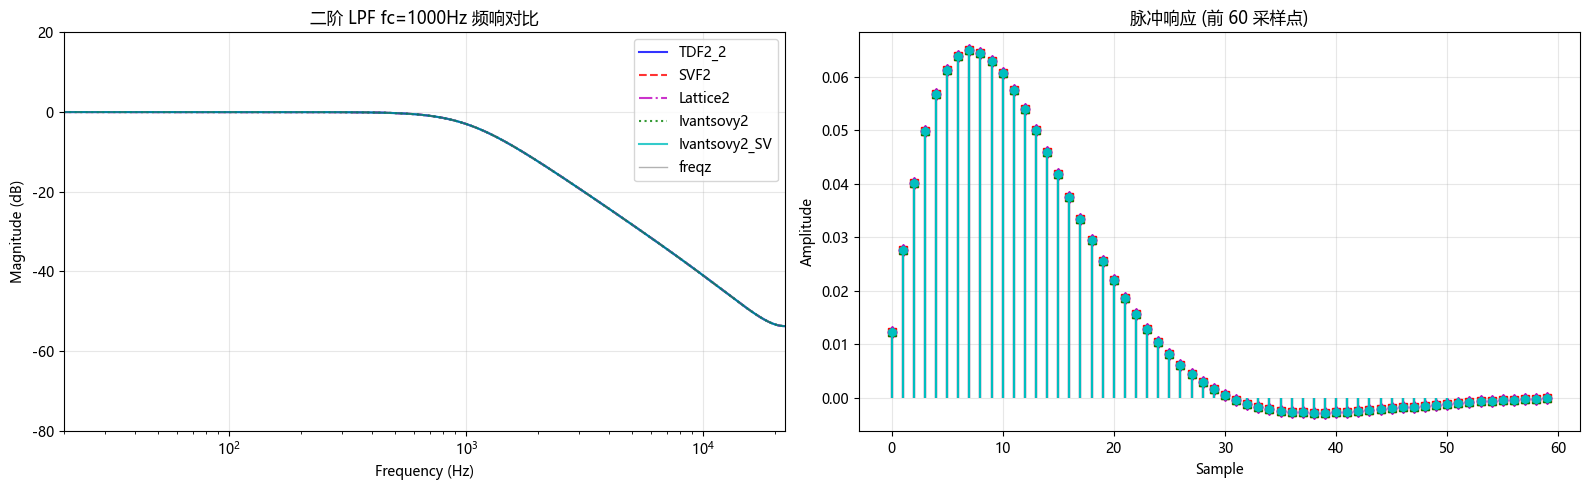

--- LPF 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 1.30e-18
TDF2_2          vs Lattice2         RMS: 2.83e-17
TDF2_2          vs Ivantsovy2       RMS: 7.33e-19
TDF2_2          vs Ivantsovy2_SV    RMS: 8.89e-17
SVF2            vs Lattice2         RMS: 2.77e-17
SVF2            vs Ivantsovy2       RMS: 9.92e-19
SVF2            vs Ivantsovy2_SV    RMS: 8.99e-17
Lattice2        vs Ivantsovy2       RMS: 2.82e-17
Lattice2        vs Ivantsovy2_SV    RMS: 9.71e-17
Ivantsovy2      vs Ivantsovy2_SV    RMS: 8.92e-17

===== 二阶 HPF fc=1000Hz =====
  b = [0.9041591303, -1.8083182606, 0.9041591303]
  a = [1.0000000000, -1.7991329919, 0.8175111992]


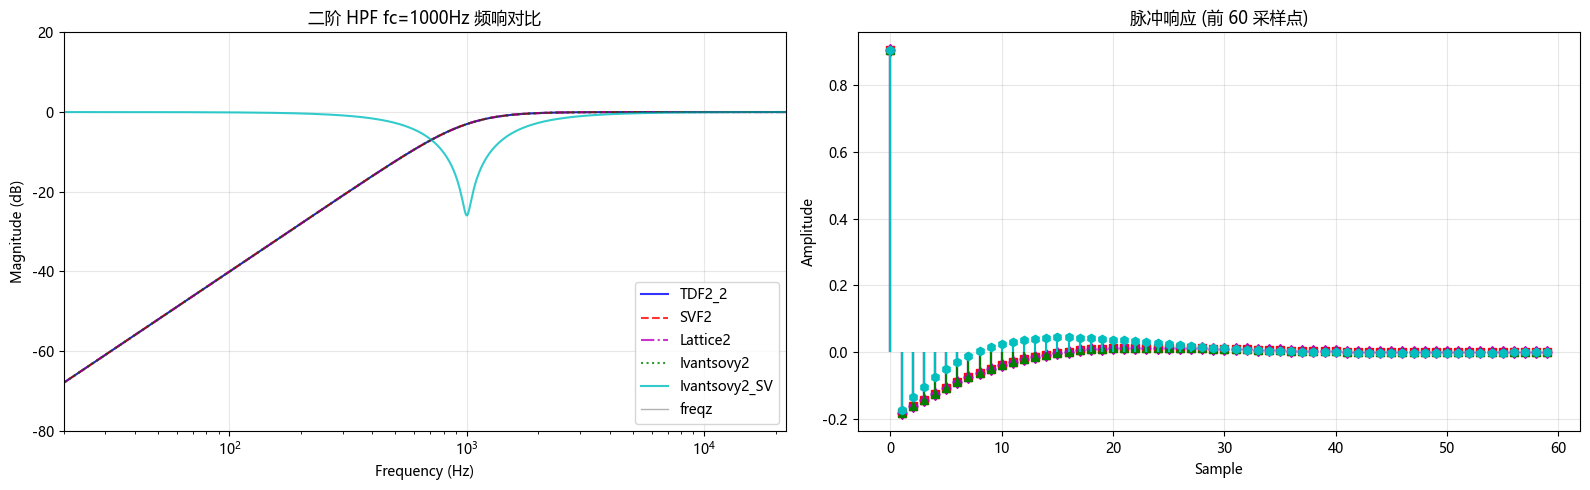

--- HPF 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 7.66e-18
TDF2_2          vs Lattice2         RMS: 4.24e-17
TDF2_2          vs Ivantsovy2       RMS: 7.65e-18
TDF2_2          vs Ivantsovy2_SV    RMS: 2.48e-03
SVF2            vs Lattice2         RMS: 4.94e-17
SVF2            vs Ivantsovy2       RMS: 1.19e-18
SVF2            vs Ivantsovy2_SV    RMS: 2.48e-03
Lattice2        vs Ivantsovy2       RMS: 4.94e-17
Lattice2        vs Ivantsovy2_SV    RMS: 2.48e-03
Ivantsovy2      vs Ivantsovy2_SV    RMS: 2.48e-03

===== 二阶 BPF fc=1000Hz =====
  b = [0.1491786952, -0.1160564092, -0.0331222860]
  a = [1.0000000000, -1.7991329919, 0.8175111992]


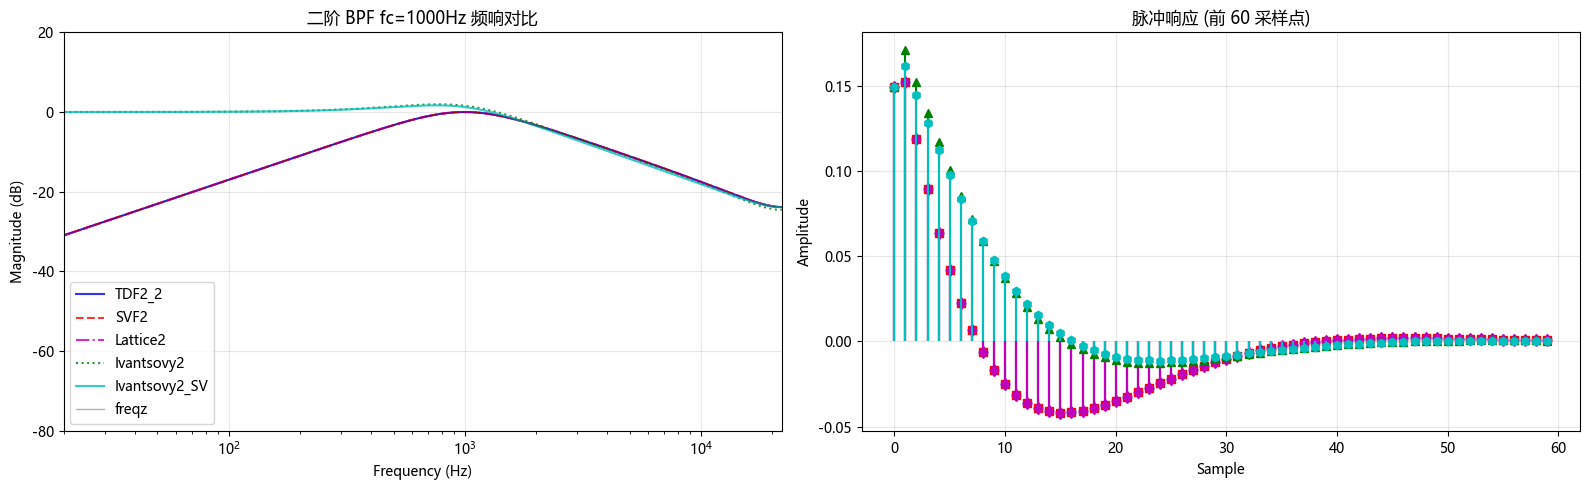

--- BPF 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 6.67e-18
TDF2_2          vs Lattice2         RMS: 2.56e-17
TDF2_2          vs Ivantsovy2       RMS: 2.49e-03
TDF2_2          vs Ivantsovy2_SV    RMS: 2.48e-03
SVF2            vs Lattice2         RMS: 2.05e-17
SVF2            vs Ivantsovy2       RMS: 2.49e-03
SVF2            vs Ivantsovy2_SV    RMS: 2.48e-03
Lattice2        vs Ivantsovy2       RMS: 2.49e-03
Lattice2        vs Ivantsovy2_SV    RMS: 2.48e-03
Ivantsovy2      vs Ivantsovy2_SV    RMS: 1.77e-04

===== 二阶 Notch fc=1000Hz =====
  b = [0.9068915804, -1.7954049535, 0.9068915804]
  a = [1.0000000000, -1.7991329919, 0.8175111992]


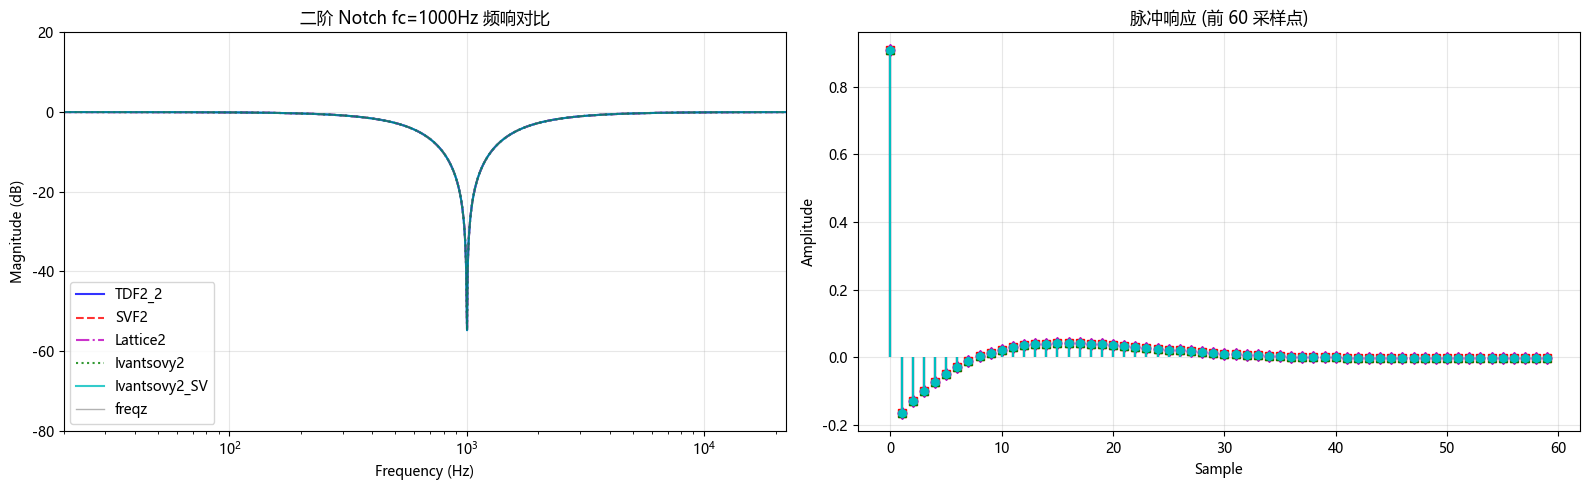

--- Notch 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 1.70e-17
TDF2_2          vs Lattice2         RMS: 3.21e-17
TDF2_2          vs Ivantsovy2       RMS: 3.23e-17
TDF2_2          vs Ivantsovy2_SV    RMS: 1.25e-16
SVF2            vs Lattice2         RMS: 2.12e-17
SVF2            vs Ivantsovy2       RMS: 1.56e-17
SVF2            vs Ivantsovy2_SV    RMS: 1.22e-16
Lattice2        vs Ivantsovy2       RMS: 1.76e-17
Lattice2        vs Ivantsovy2_SV    RMS: 1.23e-16
Ivantsovy2      vs Ivantsovy2_SV    RMS: 1.20e-16

===== 二阶 APF fc=1000Hz =====
  b = [0.8175111992, -1.7991329919, 1.0000000000]
  a = [1.0000000000, -1.7991329919, 0.8175111992]


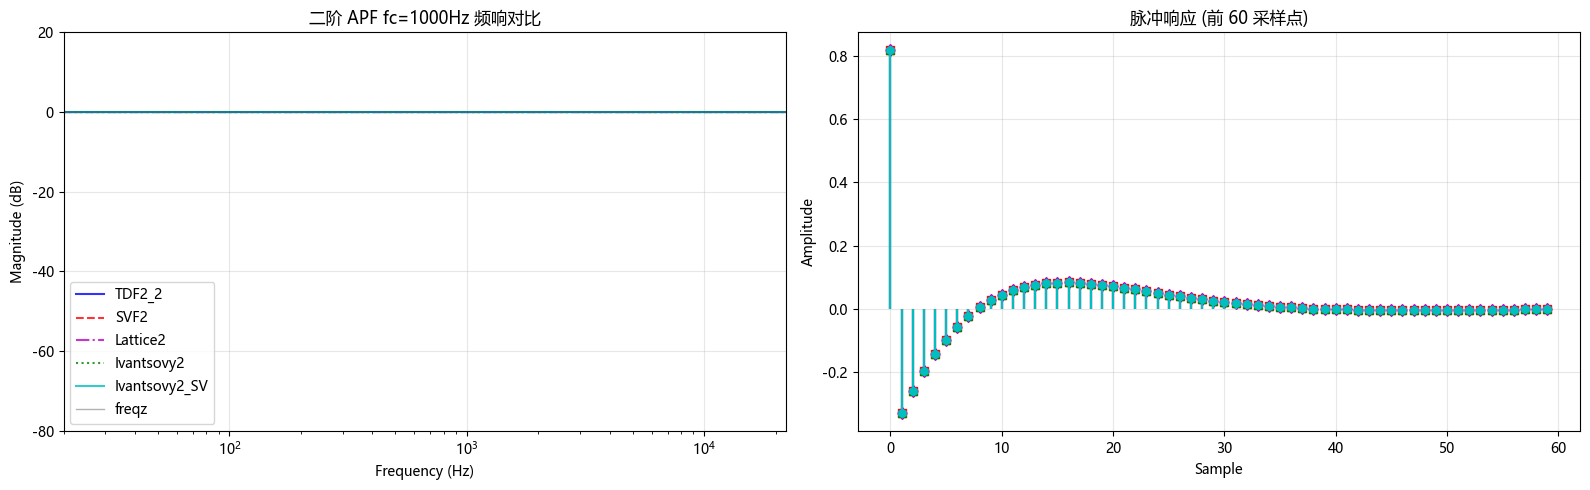

--- APF 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 3.50e-18
TDF2_2          vs Lattice2         RMS: 4.67e-17
TDF2_2          vs Ivantsovy2       RMS: 1.60e-17
TDF2_2          vs Ivantsovy2_SV    RMS: 1.78e-16
SVF2            vs Lattice2         RMS: 4.48e-17
SVF2            vs Ivantsovy2       RMS: 1.56e-17
SVF2            vs Ivantsovy2_SV    RMS: 1.78e-16
Lattice2        vs Ivantsovy2       RMS: 3.68e-17
Lattice2        vs Ivantsovy2_SV    RMS: 1.89e-16
Ivantsovy2      vs Ivantsovy2_SV    RMS: 1.77e-16

===== 二阶 BSF fc=1000Hz =====
  b = [1.1212345652, -1.8848383316, 0.7827718524]
  a = [1.0000000000, -1.8738002844, 0.8929683704]


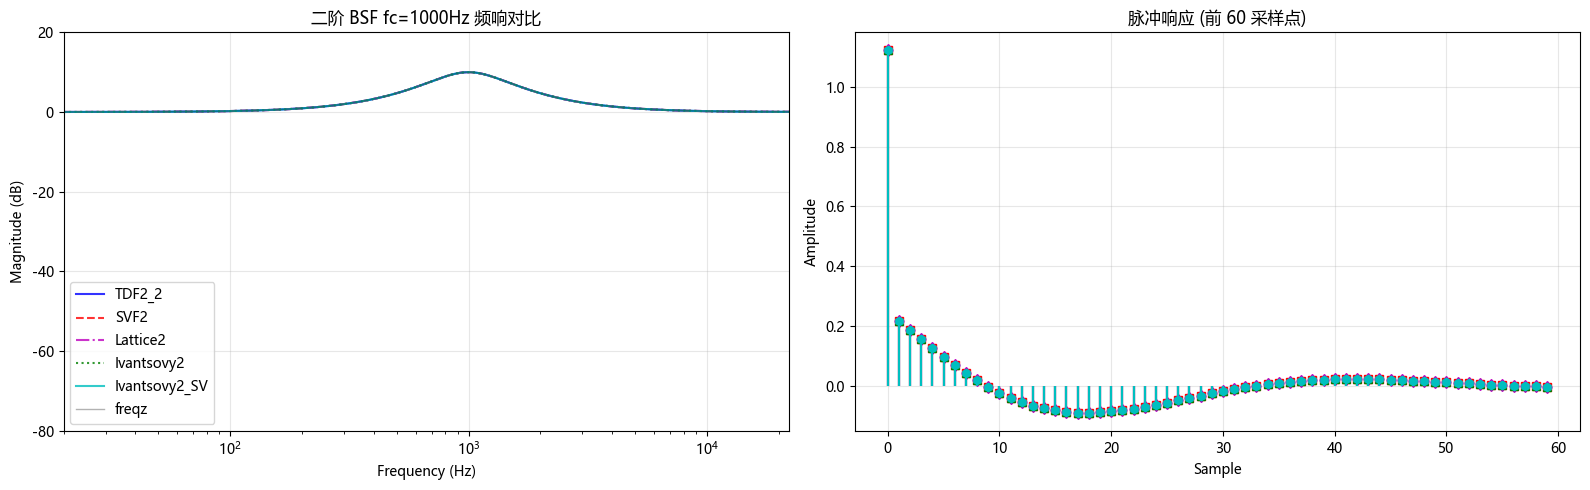

--- BSF 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 1.43e-17
TDF2_2          vs Lattice2         RMS: 4.69e-17
TDF2_2          vs Ivantsovy2       RMS: 1.28e-17
TDF2_2          vs Ivantsovy2_SV    RMS: 3.73e-16
SVF2            vs Lattice2         RMS: 5.32e-17
SVF2            vs Ivantsovy2       RMS: 4.36e-18
SVF2            vs Ivantsovy2_SV    RMS: 3.73e-16
Lattice2        vs Ivantsovy2       RMS: 5.12e-17
Lattice2        vs Ivantsovy2_SV    RMS: 3.89e-16
Ivantsovy2      vs Ivantsovy2_SV    RMS: 3.75e-16

===== 二阶 LSF fc=1000Hz =====
  b = [1.0604769297, -1.8376812209, 0.8107191843]
  a = [1.0000000000, -1.8491283048, 0.8597266446]


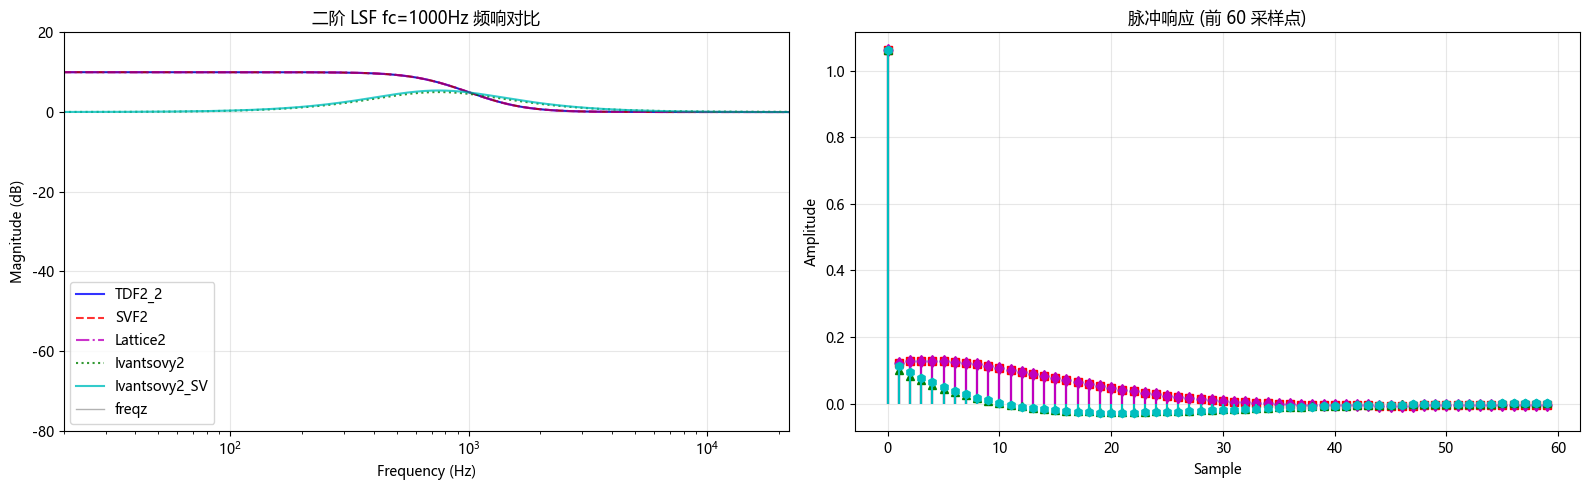

--- LSF 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 1.86e-18
TDF2_2          vs Lattice2         RMS: 2.17e-17
TDF2_2          vs Ivantsovy2       RMS: 4.65e-03
TDF2_2          vs Ivantsovy2_SV    RMS: 4.64e-03
SVF2            vs Lattice2         RMS: 2.15e-17
SVF2            vs Ivantsovy2       RMS: 4.65e-03
SVF2            vs Ivantsovy2_SV    RMS: 4.64e-03
Lattice2        vs Ivantsovy2       RMS: 4.65e-03
Lattice2        vs Ivantsovy2_SV    RMS: 4.64e-03
Ivantsovy2      vs Ivantsovy2_SV    RMS: 2.48e-04

===== 二阶 HSF fc=1000Hz =====
  b = [2.9819391366, -5.5139880608, 2.5636525284]
  a = [1.0000000000, -1.7328818473, 0.7644854514]


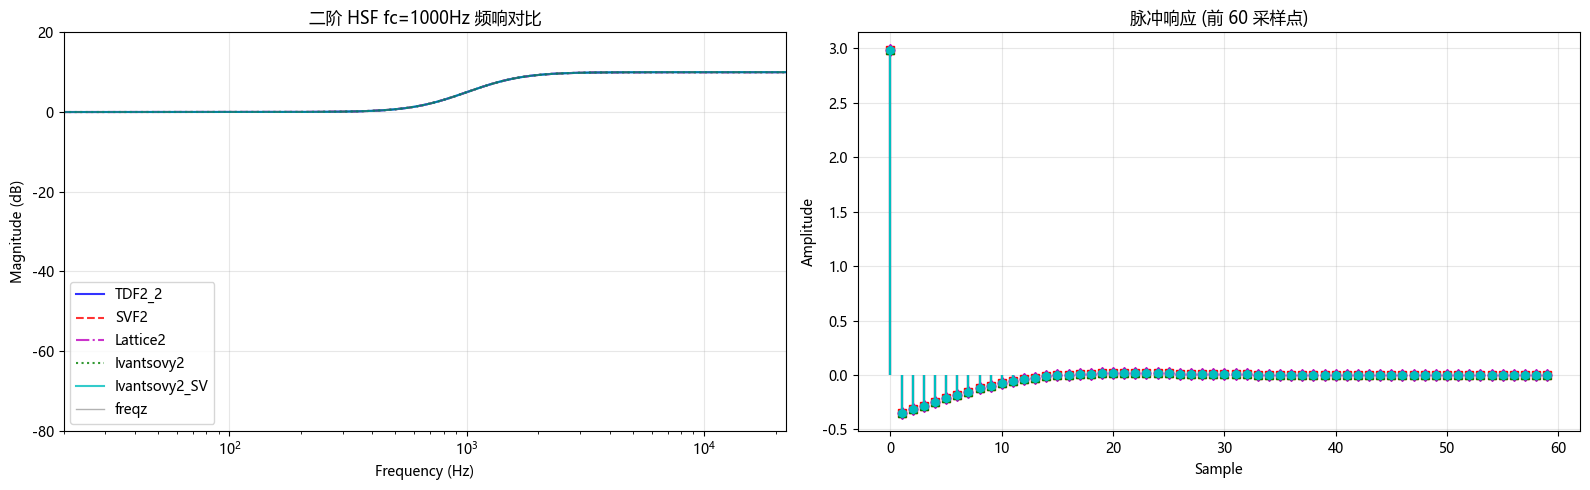

--- HSF 脉冲响应差异 (RMS) ---
TDF2_2          vs SVF2             RMS: 4.97e-17
TDF2_2          vs Lattice2         RMS: 3.43e-17
TDF2_2          vs Ivantsovy2       RMS: 4.83e-17
TDF2_2          vs Ivantsovy2_SV    RMS: 5.19e-17
SVF2            vs Lattice2         RMS: 1.60e-17
SVF2            vs Ivantsovy2       RMS: 4.05e-18
SVF2            vs Ivantsovy2_SV    RMS: 3.53e-17
Lattice2        vs Ivantsovy2       RMS: 1.48e-17
Lattice2        vs Ivantsovy2_SV    RMS: 3.45e-17
Ivantsovy2      vs Ivantsovy2_SV    RMS: 3.41e-17


In [89]:
# ==========================================
# 二阶滤波器对比测试函数
# ==========================================

def test_second_order(filter_type, fc=1000.0, fs=44100.0, sigma=2.0, zeta=1.0/np.sqrt(2)):
    """测试五种二阶滤波器结构的脉冲响应一致性"""
    b, a = get_second_order_coefficients_v2(filter_type, fc, fs, zeta=zeta, sigma=sigma)
    v3 = get_second_order_coefficients_v3(filter_type, fc, fs, zeta=zeta, sigma=sigma)
    v4 = get_second_order_coefficients_v4(filter_type, fc, fs, zeta=zeta, sigma=sigma)
    name_map = {"lp": "LPF", "hp": "HPF", "bp": "BPF", "bs": "BSF",
                "ap": "APF", "notch": "Notch", "peak": "Peak", "ls": "LSF", "hs": "HSF"}
    name = name_map.get(filter_type, filter_type.upper())
    print(f"\n===== 二阶 {name} fc={fc}Hz =====")
    print(f"  b = [{b[0]:.10f}, {b[1]:.10f}, {b[2]:.10f}]")
    print(f"  a = [{a[0]:.10f}, {a[1]:.10f}, {a[2]:.10f}]")

    tdf2 = TDF2_2(); svf = SVF2(); lat = Lattice2(); iv2 = Ivantsovy2(); iv_sv = Ivantsovy2_StateVariable()
    tdf2.set(b, a); svf.set(b, a); lat.set(b, a); iv2.set(*v3); iv_sv.set(*v4)

    N = 8192
    impulse = np.zeros(N); impulse[0] = 1.0

    out_tdf2 = np.array([tdf2.tick(x) for x in impulse])
    out_svf  = np.array([svf.tick(x)  for x in impulse])
    out_lat  = np.array([lat.tick(x)  for x in impulse])
    iv2 = Ivantsovy2(); iv2.set(*v3)
    iv_sv = Ivantsovy2_StateVariable(); iv_sv.set(*v4)
    out_iv2   = np.array([iv2.tick(x)   for x in impulse])
    out_iv_sv = np.array([iv_sv.tick(x) for x in impulse])

    freq = np.fft.rfftfreq(N, 1/fs)
    w, h_ref = signal.freqz(b, a, worN=N, fs=fs)
    H_ref = 20 * np.log10(np.abs(h_ref) + 1e-15)

    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 1)
    for data, c, ls in [(out_tdf2, 'b', '-'), (out_svf, 'r', '--'), (out_lat, 'm', '-.'), (out_iv2, 'g', ':'), (out_iv_sv, 'c', '-')]:
        H = 20 * np.log10(np.abs(np.fft.rfft(data)) + 1e-15)
        plt.plot(freq, H, c+ls, lw=1.5, alpha=0.8)
    plt.plot(w, H_ref, 'k-', label='freqz ref', lw=1, alpha=0.3)
    plt.xscale('log'); plt.xlim(20, fs/2); plt.ylim(-80, 20)
    plt.xlabel('Frequency (Hz)'); plt.ylabel('Magnitude (dB)')
    plt.title(f'二阶 {name} fc={fc}Hz 频响对比')
    plt.grid(True, alpha=0.3); plt.legend(['TDF2_2','SVF2','Lattice2','Ivantsovy2','Ivantsovy2_SV','freqz'])

    plt.subplot(1, 2, 2)
    n_show = 60
    for data, c, m in [(out_tdf2, 'b', 'o'), (out_svf, 'r', 's'), (out_lat, 'm', 'd'), (out_iv2, 'g', '^'), (out_iv_sv, 'c', 'h')]:
        plt.stem(range(n_show), data[:n_show], linefmt=c+'-', markerfmt=c+m, basefmt=' ')
    plt.xlabel('Sample'); plt.ylabel('Amplitude')
    plt.title('脉冲响应 (前 60 采样点)'); plt.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    pairs = [("TDF2_2", out_tdf2), ("SVF2", out_svf), ("Lattice2", out_lat), ("Ivantsovy2", out_iv2), ("Ivantsovy2_SV", out_iv_sv)]
    print(f"--- {name} 脉冲响应差异 (RMS) ---")
    for i, (n1, o1) in enumerate(pairs):
        for n2, o2 in pairs[i+1:]:
            print(f"{n1:15s} vs {n2:15s}  RMS: {np.sqrt(np.mean((o1-o2)**2)):.2e}")

# === 运行测试 ===
test_second_order("lp", 1000)
test_second_order("hp", 1000)
test_second_order("bp", 1000)
test_second_order("notch", 1000)
test_second_order("ap", 1000)
test_second_order("bs", 1000)
test_second_order("ls", 1000)
test_second_order("hs", 1000)